# Programming exercise 1: Single particle in a 1D potential

Due on Monday, 20.04.2026, 20h

## Defining the problem

We want to calculate the eigenenergies and eigenfunction of a quantum particle in a one-dimensional potential, i.e. solve the eigenvalue problem

$$\left[-\frac{1}{2} \partial_{x}^2 + V(x)\right] \phi(x) = E \phi(x)$$

by representing the wave function $\phi(x)$ on a discrete spatial grid.

In [74]:
# load standard libraries

import numpy as np   # standard numerics library

import matplotlib.pyplot as plt   # for making plots

import scipy as sc

#%matplotlib inline

### Exercise 1

Warmup: Consider the harmonic oscillator $V(x)=\frac{1}{2}x^2$. Plot the analytical solutions of the eigenstates on a spatial grid. Plot the lowest 6 eigenfunctions. Useful functions: `scipy.special.hermite()`, `np.linspace()`. Always use numpy arrays!

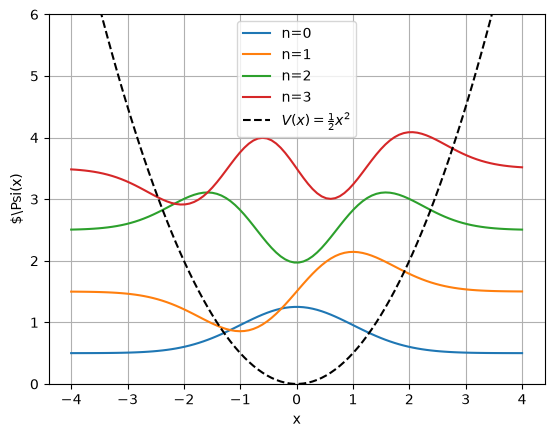

In [75]:
def get_ho_wf(n):
    def ho_wf(x):
        return sc.special.hermite(n)(x) * np.exp(-x**2/2) / np.sqrt(2**n * sc.special.factorial(n) * np.sqrt(np.pi))
    return ho_wf

x = np.linspace(-4, 4, 100)
for i in range(4):
    plt.plot(x, get_ho_wf(i)(x) + i + 0.5, label=f'n={i}')
plt.plot(x, x**2 / 2, 'k--', label=r'$V(x) = \frac{1}{2}x^2$')

plt.legend()
plt.xlabel('x')
plt.ylabel(r'$\Psi(x)')
plt.ylim(0, 6)
plt.grid()

### Exercise 2

Solve the eigenproblem using `numpy.linalg.eigh()`.
Use a grid size of 20 length units and 401 gridpoints as a test case and plot the lowest 6 eigenfunctions.

Hints: `eigh()` is for Hermitian matrices, which have real eigenvalues. It returns the eigenvalues and eigenvectors already sorted with increasing eigenvalues. You could also use `numpy.linalg.eig()`, which also works for matrices with in general complex eigenvalues, but then you would have to sort them to get the ground state and lowest lying excited states, e.g. using `np.argsort()`. Remember that the eigenvectors are the *columns* of the array returned by `eigh()`!

Useful functions: `np.diag()`, `np.ones()`

Optional: Use an interactive function to look at the eigenfunctions systematically. The following example helps you with this. It allows you to click through the eigenfunctions one by one.

In [76]:
from ipywidgets import interactive, fixed

def make_H(x, V):
    dx = x[1] - x[0]
    K = (
        -0.5 * np.diag(np.ones(len(x)-1), -1)
        + np.diag(np.ones(len(x)))
        - 0.5 * np.diag(np.ones(len(x)-1), 1)
    ) / dx**2
    V = np.diag(V(x))
    return K + V

def solve_H(x, H):
    evals, evecs = np.linalg.eigh(H)
    evecs /= (x[1] - x[0])**0.5
    return evals, evecs

x = np.linspace(-10, 10, 401)
H = make_H(x, lambda x: 0.5 * x**2)
evals, evecs = solve_H(x, H)

def plot_func(evals, evecs,k):
    plt.plot(x, evecs[:, k] + evals[k], label=f'Numerical n={k}')
    plt.plot(x, 0.5 * x**2, 'k--', label=r'$V(x) = \frac{1}{2}x^2$')
    plt.plot(x, get_ho_wf(k)(x) + evals[k], '--', label=f'Analytical n={k}')
    plt.title(f'k = {k}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.ylim(0, 2*evals[k])
    plt.grid()
    plt.legend()

interactive(plot_func, evals=fixed(evals), evecs=fixed(evecs), k=(0,10))

interactive(children=(IntSlider(value=5, description='k', max=10), Output()), _dom_classes=('widget-interact',…

In [77]:
from numpy import linalg as LA   # matrix diagonalization and more linear algebra functions

Set up the problem and solve it using `eigh()`.

Print the resulting lowest eigenvalues and plot eigenfunctions.

### Exercise 3 (optional)

Having shown that the numerical diagonalization qualitatively gives the desired result, we now want to analyse its precision more quantitatively.

- Check the convergence of the numerical solutions with respect to grid size and spacing. Compare the eigenvalues and eigenfunction to the analytical solutions.

- Which eigenvalue has the smallest numerical error and why?

- Calculate the ground state energy for different grid sizes and grid spacings and compare to the analytical solution. A systematic analysis is not necessary. Just check what happens if you use a too small grid or too few grid points.

- Compare the numerically obtained eigenfunctions to the analytical solution by plotting them on top of each other. You will notice that they are normalized differently. Why is this? How to normalize the eigenvectors obtained by exact diagonalization "properly"? Plot the difference between the probability densities of the analytical and (properly normalized) numerical solution.

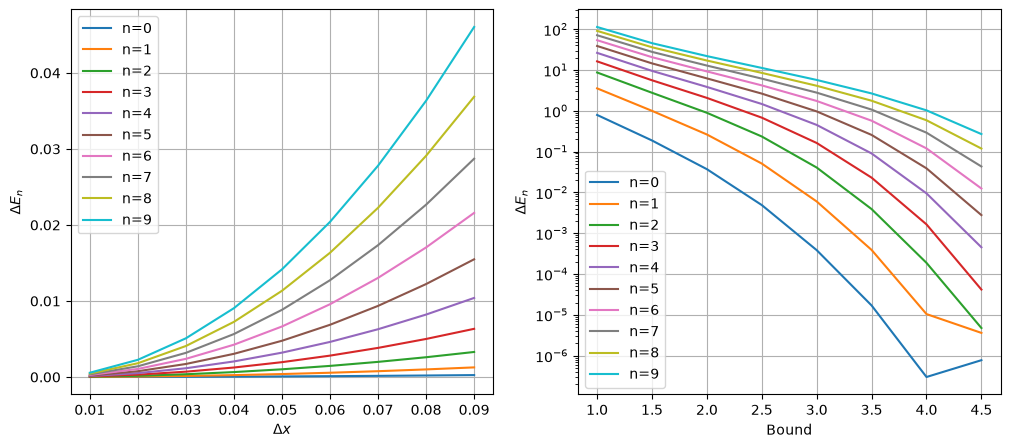

In [78]:
bounds = np.arange(1, 5, 0.5)
dxs = np.arange(0.01, 0.1, 0.01)

STATES = 10
bound_evals = np.zeros((len(bounds), STATES))
dx_evals = np.zeros((len(dxs), STATES))
analitical_evals = np.array([0.5 + n for n in range(STATES)])

for i, dx in enumerate(dxs):
    x = np.arange(-10, 10, dx)
    H = make_H(x, lambda x: 0.5 * x**2)
    evals, evecs = solve_H(x, H)
    dx_evals[i] = evals[:STATES]

for i, bound in enumerate(bounds):
    x = np.arange(-bound, bound, 0.005)
    H = make_H(x, lambda x: 0.5 * x**2)
    evals, evecs = solve_H(x, H)
    bound_evals[i] = evals[:STATES]

bound_evals = np.abs(bound_evals - analitical_evals)
dx_evals = np.abs(dx_evals - analitical_evals)

fig, (ax_dx, ax_bound) = plt.subplots(1, 2, figsize=(12, 5))
for n in range(STATES):
    ax_dx.plot(dxs, dx_evals[:, n], label=f'n={n}')
    ax_bound.plot(bounds, bound_evals[:, n], label=f'n={n}')

ax_dx.set_xlabel(r'$\Delta x$')
ax_dx.set_ylabel(r'$\Delta E_n$')
#ax_dx.set_yscale('log')
ax_dx.grid()
ax_dx.legend()

ax_bound.set_xlabel('Bound')
ax_bound.set_ylabel(r'$\Delta E_n$')
ax_bound.set_yscale('log')
ax_bound.grid()
ax_bound.legend()

### Exercise 4 (optional)

We can now use our routine to calculate bound states in any kind of potentials, where no analytical solutions are known. As an example, consider the double well potential
$$
V(x)=-\frac{1}{2}x^2 + \lambda x^4
$$
where $\lambda$ controls the height of the barrier between the wells. 

- Calculate eigenvalues and eigenfunction for some values of lambda. Plot the lowest few eigenstates and interpret your results. 

In [79]:
def double_well(l):
    return lambda x: 0.5 * (x**2 - l**2)**2

def double_well_plot(l, k):
    x = np.linspace(-5, 5, 200)
    V = double_well(l)
    H = make_H(x, V)
    evals, evecs = solve_H(x, H)
    
    plt.plot(x, evecs[:, k] + evals[k], label=f'Numerical n={k}')
    plt.plot(x, V(x), 'k--', label=r'$V(x)$')
    plt.title(f'l = {l}, k = {k}')
    plt.xlabel('x')
    plt.ylabel(f'$\\psi_{{{k}}}(x)$')
    plt.ylim(0, 2*evals[k])
    plt.grid()
    plt.legend()

interactive(double_well_plot, l=(1, 4, 0.5), k=(0, 10))

interactive(children=(FloatSlider(value=2.0, description='l', max=4.0, min=1.0, step=0.5), IntSlider(value=5, …